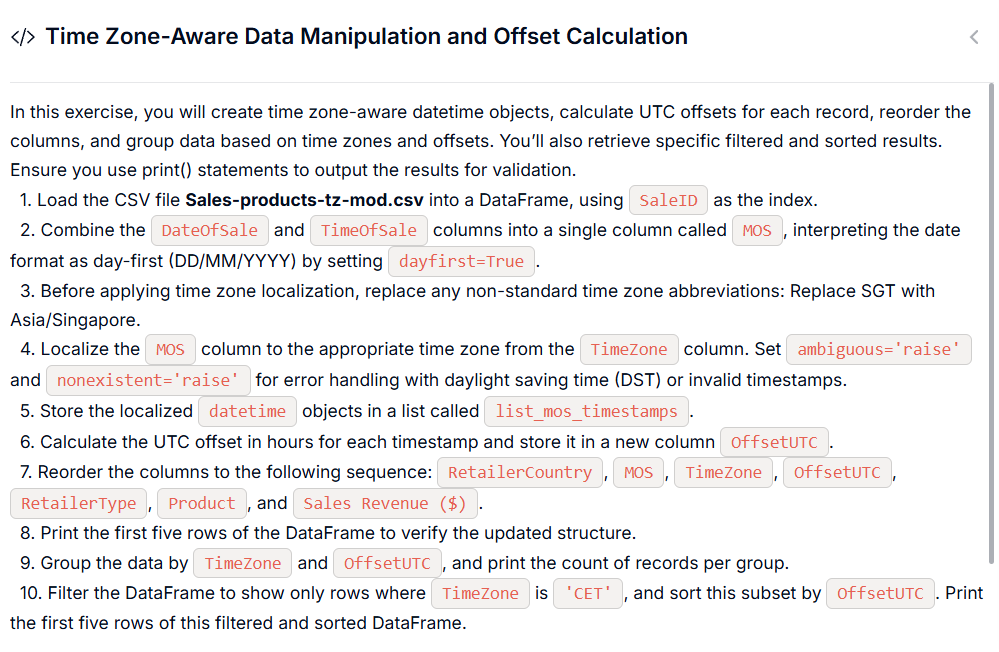

In [33]:
import pandas as pd
import pytz

# Load data with SaleID as index
data = pd.read_csv('Sales-products-tz-mod.csv', index_col='SaleID')
sales_data = data.copy()

# Step 2: Combine 'DateOfSale' and 'TimeOfSale' into a single 'MOS' column
sales_data['MOS'] = pd.to_datetime(sales_data['DateOfSale']+" "+sales_data['TimeOfSale'], dayfirst=True)

# Step 3: Replace 'SGT' with 'Asia/Singapore' for timezone consistency
sales_data['TimeZone'] = sales_data['TimeZone'].replace({'SGT':'Asia/Singapore'})

# Step 4: Localize the 'MOS' datetime to each record's timezone
list_mos_timestamps = []
for i in range(len(sales_data)):
    list_mos_timestamps.append(sales_data['MOS'].iloc[i].tz_localize(sales_data['TimeZone'].iloc[i], ambiguous='raise', nonexistent='raise'))
  
# Step 6: Calculate UTC offsets and add as 'OffsetUTC' column
sales_data['OffsetUTC'] = [timestamp.utcoffset().total_seconds() / 3600 for timestamp in list_mos_timestamps]

# Step 7: Reorder columns
column_names_reordered = ['RetailerCountry', 'MOS', 'TimeZone', 'OffsetUTC', 'RetailerType', 'Product', 'Sales Revenue ($)']
sales_data = sales_data[column_names_reordered]

# Step 8: Print first 5 rows of the updated DataFrame
print("Updated DataFrame:")
print(sales_data.head(5))

# Step 9: Group by TimeZone and OffsetUTC, then count records
grouped_data = sales_data.groupby(['TimeZone', 'OffsetUTC']).size()
print("\nGrouped Data by TimeZone and OffsetUTC:")
print(grouped_data)

# Step 10: Filter where TimeZone is 'CET' and sort by OffsetUTC
filtered_sorted_data = sales_data[sales_data['TimeZone']=='CET'].sort_values('OffsetUTC')
print("\nFiltered and Sorted Data (TimeZone == 'CET'):")
print(filtered_sorted_data.head())

Updated DataFrame:
         RetailerCountry                 MOS TimeZone  OffsetUTC  \
SaleID                                                             
SaleID_1   United States 2020-01-06 23:20:56      EST       -5.0   
SaleID_2   United States 2020-02-05 17:27:08      EST       -5.0   
SaleID_3   United States 2020-10-30 09:04:43      EST       -5.0   
SaleID_4   United States 2020-11-13 04:25:06      EST       -5.0   
SaleID_5           Italy 2020-12-06 11:15:47      CET        1.0   

           RetailerType                    Product  Sales Revenue ($)  
SaleID                                                                 
SaleID_1  Outdoors Shop  TrailChef Deluxe Cook Set              200.0  
SaleID_2  Outdoors Shop     TrailChef Double Flame                7.0  
SaleID_3  Outdoors Shop                  Star Dome               20.0  
SaleID_4  Outdoors Shop               Star Gazer 2               40.0  
SaleID_5  Outdoors Shop       Canyon Mule Carryall              150.5  
